# I_loop — Current-loop transfer functions

Small-signal / AC transfer function of every **marked stage** of the current control loop on
page 3 of `stepbystep/simple loops.pdf` (KiCad sheet `I_loop.kicad_sch`).

Every component value is a **variable** in the *Parameters* cell — edit and re-run to explore.

---
### The loop (verified from the KiCad netlist)
```
  V_set ->(+)|                                    +36V
           |  U3  |->D2->  Q3 (g_m3=1/R15) -> Q4 (beta) --,  i_c4
  V_fb --R8-(-)|   error        driver          PNP Darl. |   node "out"
           ^   amp/comp                                   v
           |                [ R19+C6 ] || [ R20 load ]   <- BOTH return to "sh", not GND!
           |                                              |   node "sh"
           |                                            [ R21 ]  200m shunt
           |          U4 non-inv. x12 (R16,R17)           |
           '---------  V_fb = 12 * R21 * I  <-------------+--> GND
```

| Box | Stage | Transfer function | Units |
|----|-------|-------------------|-------|
| U3 | Error amp / **compensator** | $H_1=-Z_f/R_8$ (finite GBW),  $Z_f=(R_{12}+\tfrac{1}{sC_4})\parallel\tfrac{1}{sC_5}$ | V/V |
| Q3,Q4,R13,R15,D2 | **Driver + pass** | $H_2=i_{c4}/V_e=\beta_4(s)\,g_{m3}\,\tfrac{R_{13}}{R_{13}+r_d}$, TIP125 2-pole $\beta_4(s)$ | A/V |
| R19,C6,R20,R21 | **Output network** | $H_3=V_{sh}/i_{c4}=R_{21}$ — **flat, load-independent!** | $\Omega$ |
| U4 | **Feedback** sense | $H_4=V_{fb}/V_{sh}=1+\tfrac{R_{16}}{R_{17}}=12$ (+GBW pole at $\approx475\,$kHz) | V/V |

**Loop gain** $T(s)=H_1H_2H_3H_4$ (U3 inverting → 180° closes the negative feedback;
$\mathrm{PM}=180^\circ+\angle T(j\omega_c)$ at $|T|=1$).

**Key structural difference to the V loop:** the output capacitor branch $R_{19}{+}C_6$ *and*
the load $R_{20}$ both return to the **top of the shunt**, so every milliamp that $Q4$ sources
must flow through $R_{21}$. KCL therefore gives $V_{sh}=R_{21}\,i_{c4}$ **exactly** — the plant
is a flat 0.2 Ω at all frequencies, for *any* load (even a short). The load type, which
dominated the V-loop design, does not appear in the current-loop gain at all; the only
dynamics left are the TIP125 $\beta(s)$ poles and U4's GBW pole.

## 1 · Parameters — edit these

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#  COMPONENT VALUES   (I_loop, page 3 of simple loops.pdf)
#  C4 = OPTIMIZED (see sections 9/10);  R12, C5 = keep DNP!
# ============================================================
# --- Stage 1: error amplifier / compensator (U3) -----------
R8  = 10e3     # input resistor  V_fb -> U3(-)                 [ohm]
R12 = 0.0      # zero-setting R (series with C4); 0 = DNP      [ohm]  <- keep 0, see section 9
C4  = 27e-9    # feedback capacitor -> pure integrator         [F]    (optimized)
C5  = 0.0      # HF feedback cap (parallel branch); 0 = DNP    [F]
GBW = 5.7e6    # op-amp gain-bandwidth product (U3 and U4)     [Hz]
# (op-amp slew rate 2.8 V/us -- large-signal only, not in the AC model)

# --- Stage 2: driver + pass transistor (Q3,R13,R15,D2,Q4) --
R13     = 1e3    # Q3 base pull-up (bias; AC divider with rd_D2)   [ohm]
R15     = 150.0  # Q3 emitter degeneration -> g_m3 = 1/(R15+re3)   [ohm]
Q4_beta = 2000.0 # TIP125 hfe, TYP from datasheet Fig.7/9 @ 3A     [-]
                 #   (datasheet min 1000; section 10 sweeps 500..4000)
fbeta1  = 60e3   # TIP125 hfe 1st pole  (Fig.7 fit, PNP @ 3A)      [Hz]
fbeta2  = 300e3  # TIP125 hfe 2nd pole  (Fig.7 fit)                [Hz]
re3     = 0.0    # Q3 small-signal emitter r = VT/Ic3 (0 = ideal)  [ohm]
rd_D2   = 26.0   # D2 dynamic resistance ~VT/1mA bias              [ohm]
fp_pass = 1e9    # optional EXTRA pass pole (Hz); large => disabled [Hz]

# --- Stage 3: output network (R19,C6, load R20, shunt R21) -
R19 = 0.2      # ESR of output capacitor C6                    [ohm]
C6  = 10e-6    # output capacitor (returns to SHUNT TOP)       [F]
R21 = 0.2      # current shunt, sensed by U4                   [ohm]
# load R20 = R_load || (R_esrL + 1/sC_load) -- also returns to the shunt top
R_load = 100.0 # load resistance                               [ohm]
C_load = 1e-6  # load capacitance                              [F]
R_esrL = 1.0   # load-cap ESR                                  [ohm]
# Q4 non-idealities used only for the flatness check in section 4:
ro_Q4  = 2e3   # Early/output resistance of Q4                 [ohm]
Cob_Q4 = 300e-12 # TIP125 output capacitance (datasheet max)   [F]

# --- Stage 4: shunt sense amplifier (U4, non-inverting) ----
R16 = 11e3     # feedback  U4 out -> U4(-)                     [ohm]
R17 = 1e3      # U4(-) -> GND                                  [ohm]

# --- frequency axis ----------------------------------------
f = np.logspace(0, 7, 6000)     # 1 Hz .. 10 MHz
w = 2*np.pi*f
s = 1j*w
print('parameters loaded')

parameters loaded


## 2 · Stage 1 — Error amplifier / compensator (U3)

Same topology as the V loop's U1: input resistor $R_8$ from the feedback voltage, feedback
impedance $Z_f$; setpoint on the (+) input.

$$Z_f(s)=\Big(R_{12}+\frac{1}{sC_4}\Big)\ \Big\|\ \frac{1}{sC_5}
\qquad H_1(s)=-\frac{Z_f/R_8}{1+\dfrac{1+Z_f/R_8}{A(s)}},\quad A(s)=\frac{2\pi\,\mathrm{GBW}}{s}$$

With the optimized values ($R_{12}=0$, $C_5=0$) this is a **pure integrator**
$H_1=-\frac{1}{sR_8C_4}$, unity-gain at $\frac{1}{2\pi R_8C_4}\approx589\,$Hz.
Unlike the V loop **no zero is wanted** here — the plant is already flat (section 4), so a
zero would only flatten the loop gain and let the crossover wander into the TIP125 β poles
with production spread (section 9). The integrator's noise gain is 1 at HF, so U3's finite
GBW contributes almost nothing.

In [2]:
# feedback impedance (admittance form => C5=0 handled cleanly)
Z_branch = R12 + 1.0/(s*C4)         # R12 in series with C4
Y_f      = 1.0/Z_branch + s*C5      # add C5 as parallel admittance
Zf       = 1.0/Y_f

A_op = 2*np.pi*GBW/s                # op-amp open-loop gain (dominant-pole integrator model)
H1   = (Zf/R8)/(1.0 + (1.0 + Zf/R8)/A_op)   # |compensator gain| incl. finite GBW
                                    # (U3 is inverting: physical = -H1; A->inf gives Zf/R8)

## 3 · Stage 2 — Driver + pass transistor (Q3, R13, R15, D2, Q4)

Identical topology and values to the V loop's driver ($R_{15}=R_4=150\,\Omega$,
$R_{13}=R_3=1\,$k, same TIP125):

$$H_2(s)=\frac{i_{c4}}{V_e}=\underbrace{\frac{R_{13}}{R_{13}+r_d}}_{\approx0.97}
\cdot\underbrace{\frac{1}{R_{15}+r_{e3}}}_{g_{m3}}
\cdot\underbrace{\frac{\beta_{40}}{\big(1+\frac{s}{\omega_{\beta1}}\big)\big(1+\frac{s}{\omega_{\beta2}}\big)}}_{\beta_4(s)\ \text{TIP125}}
\quad[\mathrm{A/V}]$$

The two-pole $\beta$ roll-off is the TIP125 datasheet Fig. 7 fit
($f_{\beta1}\approx60\,$kHz, $f_{\beta2}\approx300\,$kHz @ 3 A); $\beta_{40}$ spreads
1000 (min)…4000 (typ peak) and the poles derate at low collector current — **these β poles are
the only real plant dynamics of the whole current loop**, so section 10 sweeps them.

In [3]:
gm3     = 1.0/(R15 + re3)           # Q3 transconductance with degeneration
diode   = R13/(R13 + rd_D2)         # D2/R13 divider  (~0.97 for rd=26)
Gm_dc   = Q4_beta * gm3 * diode     # DC transconductance V_e -> i_c4   [A/V]

beta_s  = Q4_beta / ((1 + s/(2*np.pi*fbeta1)) * (1 + s/(2*np.pi*fbeta2)))  # TIP125 Fig.7
H2      = gm3 * diode * beta_s / (1.0 + s/(2*np.pi*fp_pass))   # + optional extra pole
print('Gm_dc = %.2f A/V   beta poles at %.0f kHz / %.0f kHz' % (Gm_dc, fbeta1/1e3, fbeta2/1e3))

Gm_dc = 13.00 A/V   beta poles at 60 kHz / 300 kHz


## 4 · Stage 3 — Output network (R19, C6, load R20, shunt R21)

$Q4$'s collector current $i_{c4}$ enters node *out*. From *out* there are exactly two branches
— the output capacitor ($R_{19}{+}C_6$) and the load $R_{20}$ — and **both end on node *sh***,
the top of the shunt. From *sh* the only path to ground is $R_{21}$. KCL twice:

$$i_{R21}=i_{C6}+i_{load}=i_{c4}\qquad\Rightarrow\qquad
H_3(s)=\frac{V_{sh}}{i_{c4}}=R_{21}\ \ \text{(exactly, at every frequency, for every load)}$$

The load impedance, $C_6$ and $R_{19}$ *drop out of the loop gain completely* — they set the
voltage at *out* ($V_{out}=i\,Z_{load}$...), but the regulated variable never sees them.
This is why the shunt-return topology is so robust, and why this loop needs a completely
different compensator than the V loop.

The check below re-derives $H_3$ with $Q4$'s finite output resistance $r_o$ and output
capacitance $C_{ob}$ (300 pF max) included — these parasitic paths bypass the shunt, so the
gain drops by the current-divider ratio $\approx(Z_{load}{+}R_{21})/r_o$: up to ~5 % **static
gain error** for a light (high-impedance) load with a pessimistic $r_o=2\,$k, well under 1 %
at heavy load. Crucially it adds **no dynamics below the MHz range** — the loop *shape* is
unaffected, and a static error just lands in the calibration budget.

In [4]:
H3 = R21 * np.ones_like(np.abs(s))          # the plant: flat 0.2 ohm

# --- flatness check incl. Q4 parasitics (ro, Cob), several load types --------
print('deviation of |V_sh/i_c4| from R21 with ro=%.0f ohm, Cob=%.0f pF:' % (ro_Q4, Cob_Q4*1e12))
for name, (Rl, Cl, El) in {'R 100R':(100.0,0,0), 'R 10R':(10.0,0,0), 'short (10m)':(0.01,0,0),
                           '10R+1000uF/20m':(10.0,1000e-6,0.02)}.items():
    ZA = R19 + 1.0/(s*C6)                                    # cap branch  out -> sh
    Yl = 1.0/Rl + (1.0/(El + 1.0/(s*Cl)) if Cl > 0 else 0.0) # load branch out -> sh
    Zab = 1.0/(1.0/ZA + Yl)
    # nodal: i = V_out*(1/ro + s*Cob) + (V_out-V_sh)/Zab ;  (V_out-V_sh)/Zab = V_sh/R21
    Ypar = 1.0/ro_Q4 + s*Cob_Q4
    Vsh  = R21/(1.0 + Ypar*(Zab + R21))                      # V_sh/i_c4
    dev  = np.max(np.abs(Vsh - R21)/R21)*100
    print('  %-16s max deviation = %6.3f %%   (plant stays flat)' % (name, dev))

deviation of |V_sh/i_c4| from R21 with ro=2000 ohm, Cob=300 pF:
  R 100R           max deviation =  4.771 %   (plant stays flat)
  R 10R            max deviation =  0.747 %   (plant stays flat)
  short (10m)      max deviation =  0.395 %   (plant stays flat)
  10R+1000uF/20m   max deviation =  0.506 %   (plant stays flat)


## 5 · Stage 4 — Shunt sense amplifier (U4)

$U4$ is a **non-inverting** amplifier: (+) input on the shunt top, gain set by
$R_{16}/R_{17}$, with the op-amp's GBW divided by the **noise gain of 12** — that puts U4's
pole at $\approx475\,$kHz, low enough to matter alongside the β poles:

$$H_4=\frac{V_{fb}}{V_{sh}}=\Big(1+\frac{R_{16}}{R_{17}}\Big)\cdot\frac{1}{1+s/\omega_{U4}}
=\frac{12}{1+s/2\pi\!\cdot\!475\,\text{kHz}},\qquad
\omega_{U4}=\frac{2\pi\,\mathrm{GBW}}{1+R_{16}/R_{17}}$$

Scale factor of the loop: $V_{fb}=12\cdot R_{21}\cdot I=2.4\,\mathrm{V/A}$, i.e. the loop
regulates $I_{out}\approx V_{set}/2.4\,$A ($\approx417\,$mA per volt).

In [5]:
H4g = 1.0 + R16/R17                                   # U4 DC gain = 12
H4  = H4g / (1.0 + s/(2*np.pi*GBW/H4g))               # + U4 GBW pole (~475 kHz)
print('H4 = %.1f  -> %.2f V/A   (I_out = %.1f mA per V_set volt)   U4 pole at %.0f kHz'
      % (H4g, H4g*R21, 1e3/(H4g*R21), GBW/H4g/1e3))

H4 = 12.0  -> 2.40 V/A   (I_out = 416.7 mA per V_set volt)   U4 pole at 475 kHz


## 6 · Bode plots of the four stages

Magnitude and phase of each stage (phase = frequency-shaping part; $U3$ and the loop are
inverting, i.e. an extra fixed 180° that realises the negative feedback).

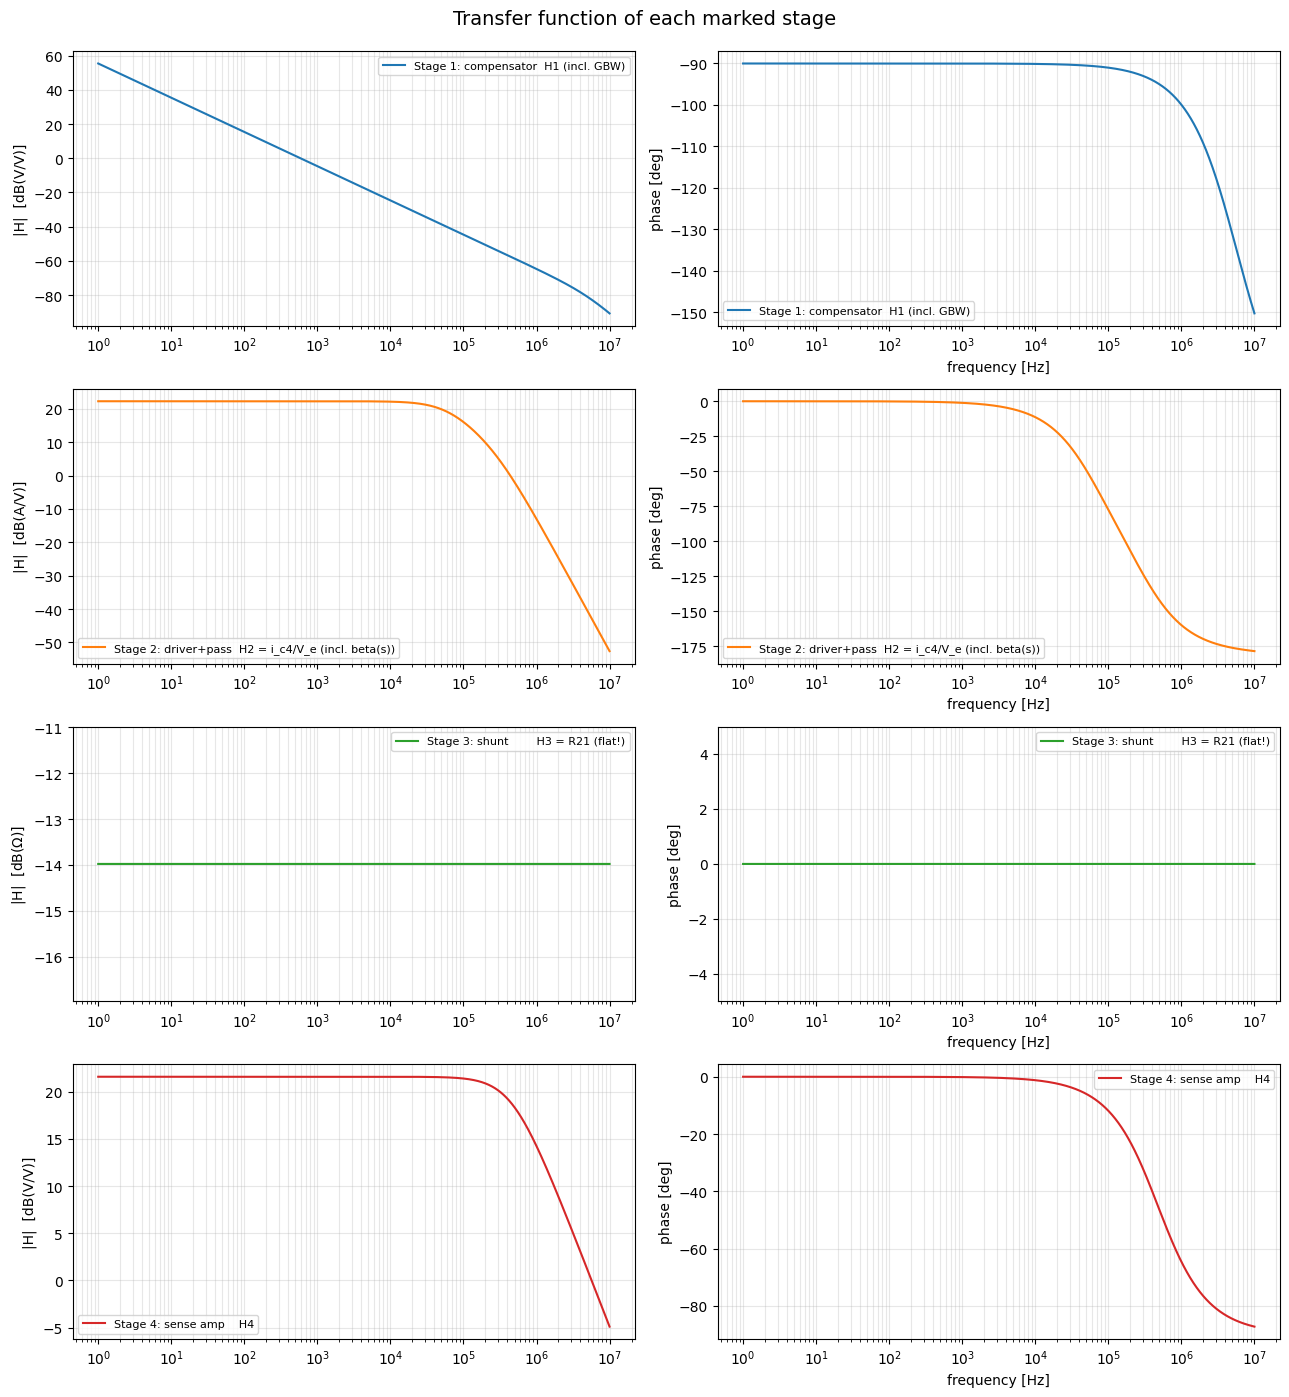

In [6]:
def _minspan(ax, data, span):
    lo, hi = np.nanmin(data), np.nanmax(data)   # widen axis so flat curves read flat
    if hi - lo < span:
        mid = 0.5*(lo+hi); ax.set_ylim(mid-span/2, mid+span/2)

def bode_pair(axm, axp, H, label, color=None, unit='dB'):
    mag = 20*np.log10(np.abs(H)); ph = np.angle(H, deg=True)
    axm.semilogx(f, mag, color=color, label=label)
    axp.semilogx(f, ph,  color=color, label=label)
    _minspan(axm, mag, 6.0); _minspan(axp, ph, 10.0)   # avoid misleading zoom
    axm.set_ylabel('|H|  ['+unit+']'); axp.set_ylabel('phase [deg]')
    for a in (axm, axp):
        a.grid(True, which='both', alpha=0.3); a.legend(loc='best', fontsize=8)
    axp.set_xlabel('frequency [Hz]')

stages = [('Stage 1: compensator  H1 (incl. GBW)', H1, 'dB(V/V)', 'C0'),
          ('Stage 2: driver+pass  H2 = i_c4/V_e (incl. beta(s))', H2, 'dB(A/V)', 'C1'),
          ('Stage 3: shunt        H3 = R21 (flat!)', H3, r'dB($\Omega$)', 'C2'),
          ('Stage 4: sense amp    H4', H4, 'dB(V/V)', 'C3')]

fig, ax = plt.subplots(4, 2, figsize=(13, 14))
for i,(name,H,unit,col) in enumerate(stages):
    bode_pair(ax[i,0], ax[i,1], H, name, color=col, unit=unit)
fig.suptitle('Transfer function of each marked stage', fontsize=14, y=0.995)
fig.tight_layout()
plt.show()

## 7 · Loop gain $T(s)=H_1H_2H_3H_4$ — stability

$$T(s)=\frac{Z_f(s)}{R_8}\cdot\beta_4(s)\,g_{m3}\cdot R_{21}\cdot H_4(s)$$

Because the plant is flat, $|T|$ is simply the integrator slope with the β/U4 poles hanging
off the top: gain crossover $f_c=\dfrac{0.97\,\beta_{40}\,R_{21}\,H_{4g}}{2\pi R_8 C_4 R_{15}}$
(while $f_c\ll f_{\beta1}$). PM $=180°+\angle T(j\omega_c)$, GM where $\angle T=-180°$.

In [7]:
T = H1 * H2 * H3 * H4              # loop gain
magT = 20*np.log10(np.abs(T))
phT  = np.unwrap(np.angle(T))*180/np.pi

def log_interp(xq, x, y):
    return np.interp(np.log10(xq), np.log10(x), y)

def crossings(y, x, level):
    out = []
    d = np.sign(y - level)
    idx = np.where(np.diff(d) != 0)[0]
    for k in idx:
        lf = np.interp(level, [y[k], y[k+1]], [np.log10(x[k]), np.log10(x[k+1])])
        out.append(10**lf)
    return out

fc_list = crossings(magT, f, 0.0)
print('--- Loop-gain summary ---')
print('DC (1 Hz) loop gain : %6.1f dB' % magT[0])
if fc_list:
    for fc in fc_list:
        pm = 180 + log_interp(fc, f, phT)
        print('gain crossover      : %8.1f Hz   PM = %+6.1f deg' % (fc, pm))
else:
    print('no 0 dB crossing in the swept range')

fp_list = crossings(phT, f, -180.0)
for fpx in fp_list:
    gm_db = -log_interp(fpx, f, magT)
    print('phase crossover     : %8.1f Hz   GM = %+6.1f dB' % (fpx, gm_db))

--- Loop-gain summary ---
DC (1 Hz) loop gain :   85.3 dB
gain crossover      :  17628.2 Hz   PM =  +68.0 deg
phase crossover     :  99464.1 Hz   GM =  +21.0 dB


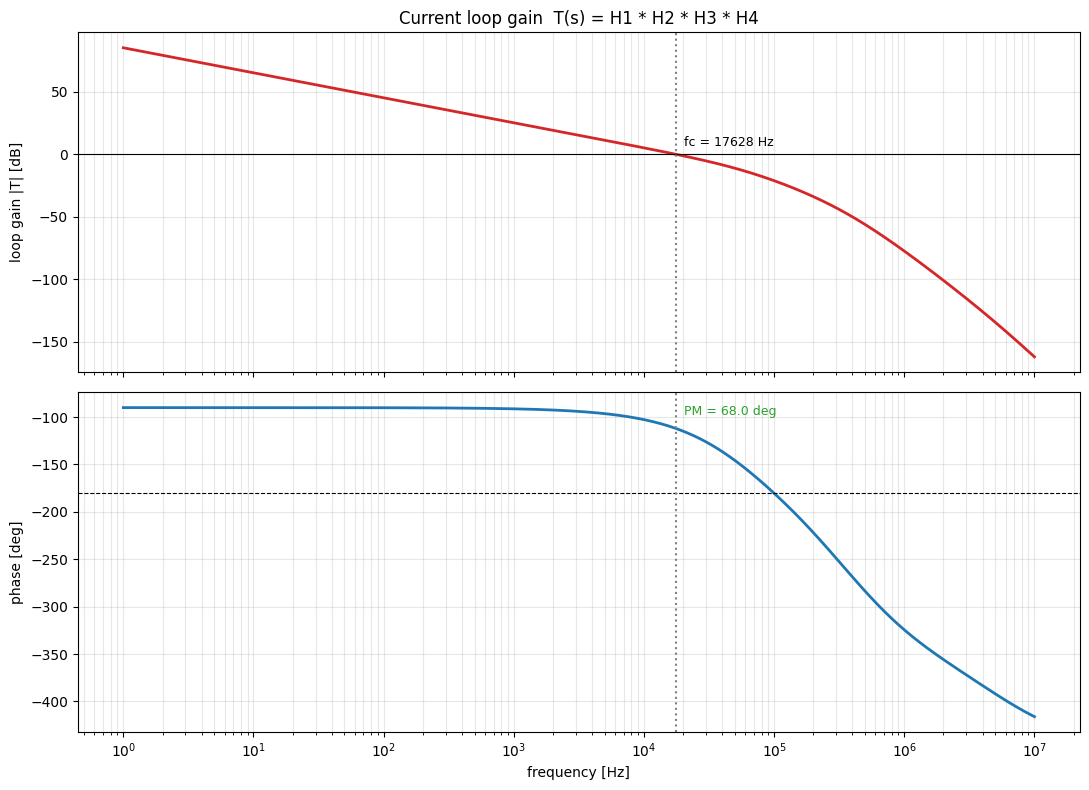

In [8]:
fig, (axm, axp) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axm.semilogx(f, magT, 'C3', lw=2, label='|T|')
axm.axhline(0, color='k', lw=0.8)
axm.set_ylabel('loop gain |T| [dB]'); axm.grid(True, which='both', alpha=0.3)
axp.semilogx(f, phT, 'C0', lw=2, label='phase T')
axp.axhline(-180, color='k', lw=0.8, ls='--')
axp.set_ylabel('phase [deg]'); axp.set_xlabel('frequency [Hz]')
axp.grid(True, which='both', alpha=0.3)

for fc in fc_list:
    pm = 180 + log_interp(fc, f, phT)
    for a in (axm, axp): a.axvline(fc, color='0.5', ls=':')
    axm.annotate('fc = %.0f Hz' % fc, (fc, 0), textcoords='offset points',
                 xytext=(6, 6), fontsize=9)
    axp.annotate('PM = %.1f deg' % pm, (fc, log_interp(fc, f, phT)),
                 textcoords='offset points', xytext=(6, 10), fontsize=9,
                 color=('C2' if pm>45 else 'C3'))
axm.set_title('Current loop gain  T(s) = H1 * H2 * H3 * H4')
fig.tight_layout(); plt.show()

## 7b · Compensator vs. the rest of the loop (loop shaping)

Overlay of the **compensator** $H_1$, **everything else** $H_{rest}=H_2H_3H_4$ and the loop
$T=H_1H_{rest}$. With the flat plant, $H_{rest}$ is just a constant
$0.97\,\beta_{40}R_{21}H_{4g}/R_{15}\approx31$ (30 dB) with the β/U4 poles — the integrator
crosses it on a clean −20 dB/dec slope, and the phase budget at crossover is −90°
(integrator) minus whatever the β poles have already taken.

--- angles at the loop crossover  |T| = 0 dB ---
  fc =  17628.2 Hz :  comp =  -90.2  rest =  -21.9  ->  loop = -112.0 deg   PM = +68.0 deg


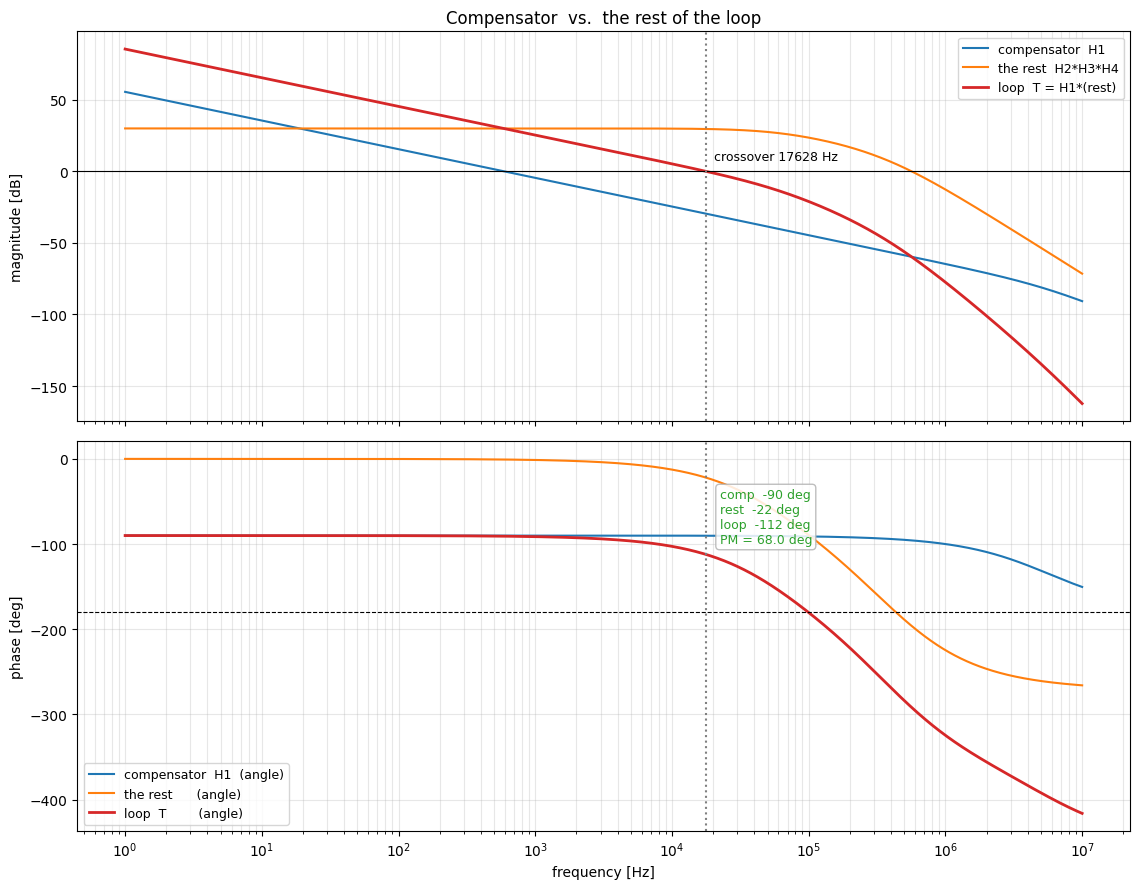

In [9]:
H_rest = H2 * H3 * H4                       # driver+pass x shunt x sense
aH1, aR, aT = (np.angle(H1, deg=True), np.unwrap(np.angle(H_rest))*180/np.pi, phT)
mH1, mR, mT = (20*np.log10(np.abs(H1)), 20*np.log10(np.abs(H_rest)), magT)
fc_cross = crossings(mT, f, 0.0)

fig, (axm, axp) = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
axm.semilogx(f, mH1, 'C0',      label='compensator  H1')
axm.semilogx(f, mR,  'C1',      label='the rest  H2*H3*H4')
axm.semilogx(f, mT,  'C3', lw=2, label='loop  T = H1*(rest)')
axm.axhline(0, color='k', lw=0.8)
axm.set_ylabel('magnitude [dB]'); axm.grid(True, which='both', alpha=0.3)
axm.legend(loc='upper right', fontsize=9)

axp.semilogx(f, aH1, 'C0',      label='compensator  H1  (angle)')
axp.semilogx(f, aR,  'C1',      label='the rest      (angle)')
axp.semilogx(f, aT,  'C3', lw=2, label='loop  T        (angle)')
axp.axhline(-180, color='k', lw=0.8, ls='--')
axp.set_ylabel('phase [deg]'); axp.set_xlabel('frequency [Hz]')
axp.grid(True, which='both', alpha=0.3); axp.legend(loc='lower left', fontsize=9)

print('--- angles at the loop crossover  |T| = 0 dB ---')
for fc in fc_cross:
    a1 = log_interp(fc, f, aH1); ar = log_interp(fc, f, aR); at = log_interp(fc, f, aT)
    for a in (axm, axp): a.axvline(fc, color='0.5', ls=':')
    axm.annotate('crossover %.0f Hz' % fc, (fc, 0), textcoords='offset points',
                 xytext=(6, 8), fontsize=9)
    axp.annotate('comp  %+.0f deg\nrest  %+.0f deg\nloop  %+.0f deg\nPM = %.1f deg'
                 % (a1, ar, at, 180+at), (fc, at), textcoords='offset points',
                 xytext=(10, 6), fontsize=9, va='bottom',
                 color=('C2' if 180+at>45 else 'C3'),
                 bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
    print('  fc = %8.1f Hz :  comp = %+6.1f  rest = %+6.1f  ->  loop = %+6.1f deg   PM = %+5.1f deg'
          % (fc, a1, ar, at, 180+at))

axm.set_title('Compensator  vs.  the rest of the loop')
fig.tight_layout(); plt.show()

## 8 · Closed-loop step response  ($V_{set}\to I_{out}$)

$$\frac{I_{out}}{V_{set}}=\frac{G_m(s)\,(1+Z_f/R_8)}{1+T},\qquad
T=\frac{Z_f}{R_8}\,G_m(s)\,R_{21}\,H_4(s)$$

DC value $=1/(R_{21}H_{4g})=1/2.4\approx417\,$mA/V. β poles and the U4 pole are in the
polynomial model (U3's GBW omitted — MHz range).

**Expect a huge transient spike — and understand it.** The plant has *no inertia* (flat
$R_{21}$, no output pole in the current path), so a $V_{set}$ edge feeds through the
noise-gain term $(1+Z_f/R_8)\to1$ straight to $V_e$ and commands
$\Delta I\approx G_m\Delta V_{set}\approx13\,$A/V for the few µs it takes the loop
($1/2\pi f_c\approx9\,$µs) to integrate it away — the small-signal model shows this as an
overshoot of >2000 %. It is **not** ringing (it decays monotonically). In hardware the spike
is clipped by large-signal limits (U3 output swing / 2.8 V/µs slew, Q3's emitter resistor,
the supply itself), but the lesson is real: **the current setpoint must never step hard** —
use an RC prefilter on $V_{set}$ with $\tau\gg1/2\pi f_c$ (e.g. 10 k + 100 n) or a DAC ramp.
Note also that in the real supply the I loop usually *enters* regulation by taking over from
the V loop through the D1/D2 OR (integrator wind-down) — a large-signal event; this
small-signal step applies to operation *while* current-limiting.

DC gain I_out/V_set = 0.4167 A/V   (final = 416.7 mA for a 1.00 V step)
overshoot = 2267 %   t_peak = 5.9 us   2% settling = 48 us


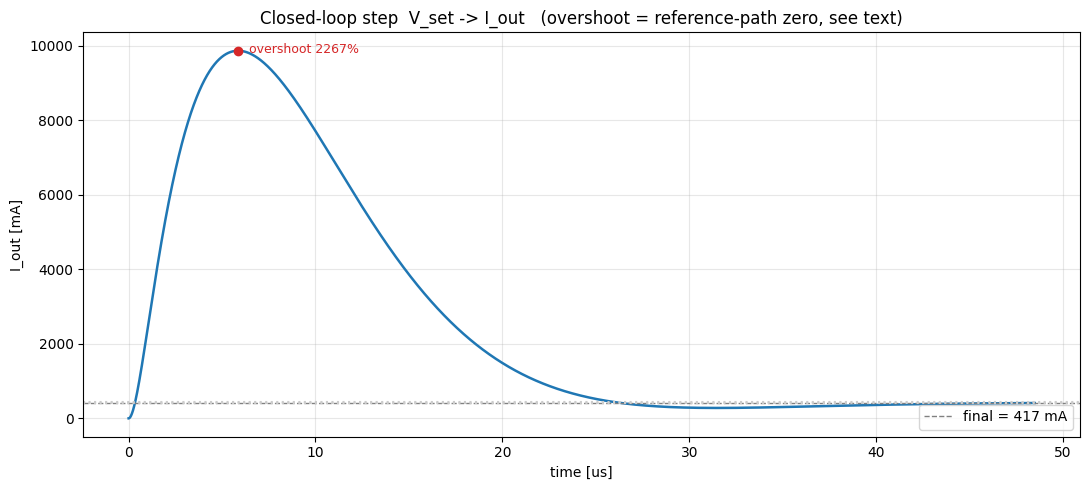

In [10]:
# ---- closed loop I_out/V_set = Gm(s)*(1+Zf/R8) / (1+T)  as polynomials in s ----
def pmul(a,b): return np.polymul(a,b)
def padd(a,b): return np.polyadd(a,b)
def par(n1,d1,n2,d2):
    return pmul(n1,n2), padd(pmul(n1,d2), pmul(n2,d1))

nb_=[R12*C4,1.0]; db_=[C4,0.0]             # Zf branch: R12 + 1/(sC4)
if C5>0: nZf,dZf = par(nb_,db_,[1.0],[C5,0.0])
else:    nZf,dZf = nb_,db_
nA, dA = nZf, pmul(dZf,[R8])               # A = Zf/R8   (U3 GBW ignored: ~MHz)

d_beta = pmul([1.0/(2*np.pi*fbeta1),1.0],[1.0/(2*np.pi*fbeta2),1.0])  # TIP125 beta poles
d_U4   = [H4g/(2*np.pi*GBW), 1.0]                                     # U4 pole at GBW/12

num_cl = pmul([Gm_dc], pmul(padd(dA,nA), d_U4))          # Gm(s)*(1+A), x d_U4/d_U4
den_cl = padd(pmul(dA, pmul(d_beta, d_U4)),
              pmul([Gm_dc*R21*H4g], nA))                 # dA*d_beta*d_U4 + nA*Gm*R21*H4g
dc_gain = np.polyval(num_cl,0.0)/np.polyval(den_cl,0.0)  # = 1/(R21*H4g)

# ---- robust step: frequency-scale s=w0*x so coeffs are O(1) ----
Vstep = 1.0                                # V_set step amplitude [V]  (edit me)
ndeg  = len(den_cl)-1
w0    = abs(den_cl[-1]/den_cl[0])**(1.0/ndeg)
scale = lambda c: np.asarray(c,float)*(w0**np.arange(len(c)-1,-1,-1))
nS, dS = scale(num_cl), scale(den_cl)

psc   = np.roots(dS)*w0
tmax  = 8.0/np.min(np.abs(psc.real))
t     = np.linspace(0.0, tmax, 6000)
try:
    from scipy import signal
    _, yn = signal.step(signal.StateSpace(*signal.tf2ss(nS, dS)), T=w0*t)
except Exception:
    ps=np.roots(dS); dd=np.polyder(dS); Ts=w0*t
    yn=np.full(Ts.shape, np.polyval(nS,0)/np.polyval(dS,0), dtype=complex)
    for p in ps: yn = yn + np.polyval(nS,p)/(p*np.polyval(dd,p))*np.exp(p*Ts)
    yn = yn.real

Iout = Vstep*yn; yf = Vstep*dc_gain
peak = Iout.max(); tp = t[np.argmax(Iout)]
overshoot = 100*(peak-yf)/yf
outside   = np.where(np.abs(Iout-yf) > 0.02*abs(yf))[0]
tset      = t[outside[-1]] if len(outside) else 0.0
print('DC gain I_out/V_set = %.4f A/V   (final = %.1f mA for a %.2f V step)' % (dc_gain, 1e3*yf, Vstep))
print('overshoot = %.0f %%   t_peak = %.1f us   2%% settling = %.0f us'
      % (overshoot, tp*1e6, tset*1e6))

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(t*1e6, Iout*1e3, 'C0', lw=1.8)
ax.axhline(yf*1e3, color='0.5', ls='--', lw=1, label='final = %.0f mA' % (yf*1e3))
ax.axhline(1.02*yf*1e3, color='0.8', ls=':'); ax.axhline(0.98*yf*1e3, color='0.8', ls=':')
ax.plot(tp*1e6, peak*1e3, 'C3o')
ax.annotate('overshoot %.0f%%' % overshoot, (tp*1e6, peak*1e3),
            textcoords='offset points', xytext=(8,-2), color='C3', fontsize=9)
ax.set_xlabel('time [us]'); ax.set_ylabel('I_out [mA]')
ax.set_title('Closed-loop step  V_set -> I_out   (overshoot = reference-path zero, see text)')
ax.grid(alpha=0.3); ax.legend(loc='lower right')
fig.tight_layout(); plt.show()

## 9 · Notes, assumptions & design rationale

**Modelling status** (same real device data as the V-loop notebook):
- $Q4$ = TIP125: two-pole $\beta(s)$ from datasheet Fig. 7 (60 k / 300 kHz @ 3 A);
  $\beta_0$ spread 1000…4000 (typ peak) and low-bias pole derating swept in §10.
- Op-amps GBW = 5.7 MHz: exact in $H_1$ (negligible — integrator noise gain 1),
  explicit 475 kHz pole in $H_4$ (noise gain 12!). Slew 2.8 V/µs = large-signal only.
- $Q4$ parasitics ($r_o$, $C_{ob}$) checked in §4 — no added dynamics; ≤ ~5 % static gain
  error at light load (calibration territory).

**Why the compensator is a *pure integrator* here (R12 = C5 = DNP):**
The plant is flat ($R_{21}$), so the integrator alone gives a clean −20 dB/dec crossover with
−90° + β-pole phase. A V-loop-style zero (R12 > 0) would flatten the compensator above
$f_z$; combined with the 8:1 β-gain spread the crossover would then slide across the flat
region straight into the β poles → phase margin collapses. Concretely: R12 = 1 k flattens
$|T|$ at ~10 dB from ~3 kHz up, pushing the crossover to ≳100 kHz at high β. **Keep R12 = 0.**

**Choosing C4** (R8 = 10 k fixed): crossover $f_c\approx31/(2\pi R_8C_4)$ at β = 2000.
- C4 = 22n: fc ≈ 21 kHz, but worst corner PM 45.7°, low-bias Spk ≈ 2.0 — edge.
- **C4 = 27n: fc ≈ 17.6 kHz, worst main PM ≥ 51°, GM ≥ 15 dB, low-bias PM ≥ 43° — chosen.**
- C4 = 47n: fc ≈ 10.4 kHz, PM ≥ 65° — use if the hardware shows less margin than modelled.

**Interaction with the V loop (not modelled):** in the real channel both error amps drive the
same pass device through the D1/D2 diode-OR; whichever demands *less* output wins. The
inactive loop's integrator saturates and must slew back before taking over — that CV↔CC
handover is a large-signal effect (op-amp slew 2.8 V/µs, integrator recharge) and should be
checked on hardware; an anti-windup clamp on the inactive integrator speeds it up.

## 10 · Corner sweep — TIP125 β spread (loads don't matter here!)

The V-loop notebook sweeps 11 load types; here that sweep is pointless by construction —
§4 shows $H_3=R_{21}$ for every load, so **the loop gain is identical for a short, a resistor
or 1000 µF**. What *does* move the loop is the TIP125:

- **β₀** ∈ {500, 1000, 2000, 4000} (min 1000, typ 2000–4000; 500 = cold/low-current pessimism),
- **low-bias corner**: $f_{\beta}$ derated to 20 k/100 kHz (Fig. 7 is @ 3 A),
- plus a demonstration column that re-computes the margins with three very different loads —
  the numbers are bit-identical.

$S_{pk}=\max|1/(1+T)|$ is the sensitivity peak ($<1.5$ well damped, $>2$ rings).

beta corner   fc [Hz]   PM [deg]   GM [dB]   Spk
----------------------------------------------------
b=500          4582      84.2      33.1   1.08
b=1000         9082      78.5      27.1   1.15
b=2000        17597      68.0      21.0   1.30
b=4000        32148      51.5      15.0   1.60
b=1k LB        8437      61.2      20.3   1.39
b=2k LB       14662      43.5      14.3   1.78

load-independence check @ b=2000 (H3 = R21 regardless of load):
  short              fc = 17597 Hz   PM = 68.0 deg   (identical -- load not in T(s))
  R 100R             fc = 17597 Hz   PM = 68.0 deg   (identical -- load not in T(s))
  10R + 1000uF/20m   fc = 17597 Hz   PM = 68.0 deg   (identical -- load not in T(s))


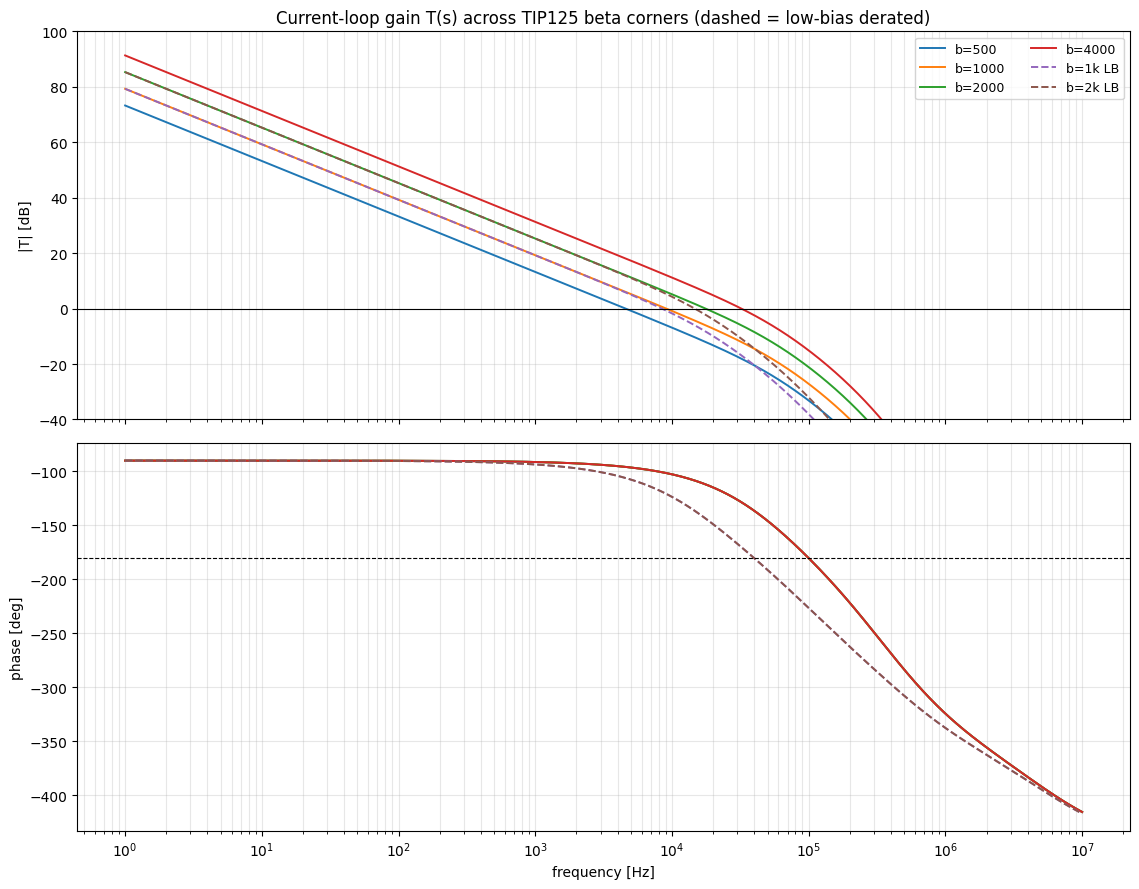

In [11]:
# ---- corner sweep: beta corners (x demo loads to show load-independence) ----
beta_corners = [
    ('b=500',   500.0, 60e3, 300e3), ('b=1000', 1000.0, 60e3, 300e3),
    ('b=2000', 2000.0, 60e3, 300e3), ('b=4000', 4000.0, 60e3, 300e3),
    ('b=1k LB',1000.0, 20e3, 100e3), ('b=2k LB',2000.0, 20e3, 100e3)]   # LB = low-bias derated

def T_corner(b0, fb1c, fb2c):
    bs = b0/((1 + s/(2*np.pi*fb1c))*(1 + s/(2*np.pi*fb2c)))
    return H1 * (gm3*diode*bs) * R21 * H4          # H1/H4 already include GBW

def margins(T):
    m = 20*np.log10(np.abs(T)); p = np.unwrap(np.angle(T))*180/np.pi
    idx = np.where(np.diff(np.sign(m)) != 0)[0]
    if len(idx) == 0: return np.nan, np.nan, np.inf, np.max(np.abs(1/(1+T))), 0
    pms, fcs = [], []
    for k in idx:
        lf = np.interp(0.0, [m[k+1], m[k]], [np.log10(f[k+1]), np.log10(f[k])])
        fcs.append(10**lf); pms.append(180.0 + np.interp(lf, np.log10(f), p))
    gm = np.inf
    for k in np.where(np.diff(np.sign(p + 180.0)) != 0)[0]:
        lf = np.interp(-180.0, [p[k], p[k+1]], [np.log10(f[k]), np.log10(f[k+1])])
        gm = min(gm, -np.interp(lf, np.log10(f), m))
    j = int(np.argmin(pms))
    return fcs[j], min(pms), gm, np.max(np.abs(1.0/(1.0+T))), len(idx)

print('beta corner   fc [Hz]   PM [deg]   GM [dB]   Spk')
print('-'*52)
for lbl, b0, f1c, f2c in beta_corners:
    fc, pm, gm, spk, nc = margins(T_corner(b0, f1c, f2c))
    print('%-9s %9.0f %9.1f %9.1f %6.2f%s'
          % (lbl, fc, pm, gm, spk, '   <-- watch' if pm < 35 or spk > 2.0 else ''))

# --- load-independence demo: identical margins for wildly different loads ----
print('\nload-independence check @ b=2000 (H3 = R21 regardless of load):')
for name in ('short', 'R 100R', '10R + 1000uF/20m'):
    fc, pm, gm, spk, _ = margins(T_corner(2000.0, 60e3, 300e3))
    print('  %-18s fc = %.0f Hz   PM = %.1f deg   (identical -- load not in T(s))' % (name, fc, pm))

# --- Bode overlay across beta corners ----------------------------------------
fig, (axm, axp) = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
for lbl, b0, f1c, f2c in beta_corners:
    T_l = T_corner(b0, f1c, f2c)
    ls = '--' if 'LB' in lbl else '-'
    axm.semilogx(f, 20*np.log10(np.abs(T_l)), ls, lw=1.4, label=lbl)
    axp.semilogx(f, np.unwrap(np.angle(T_l))*180/np.pi, ls, lw=1.4, label=lbl)
axm.axhline(0, color='k', lw=0.8); axm.set_ylabel('|T| [dB]'); axm.set_ylim(-40, 100)
axp.axhline(-180, color='k', lw=0.8, ls='--'); axp.set_ylabel('phase [deg]')
axp.set_xlabel('frequency [Hz]')
for a in (axm, axp): a.grid(True, which='both', alpha=0.3)
axm.legend(fontsize=9, ncol=2)
axm.set_title('Current-loop gain T(s) across TIP125 beta corners (dashed = low-bias derated)')
fig.tight_layout(); plt.show()